In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
from itertools import product
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from transformers import AutoTokenizer
import utils

device = 'cuda'
datasets = ['aimedical', 'codeparrotapps', 'evolcode', 'mentalhealth']
tokenizer = AutoTokenizer.from_pretrained(utils.LLM_PATH['llama3-8binst'])
def loadtext(path):
    tmp = torch.load(path, weights_only=True)
    return tmp
from utils import Eval
evaluator = Eval(tokenizer=tokenizer, device=device)

text_dict = {}
for dataset in datasets:
    text_list = utils.get_list_invert_text(dataset)
    text_dict[dataset] = sorted(text_list, key=lambda x: len(tokenizer.encode(x, add_special_tokens=False)), reverse=True)

def evalres(references_str, predictions_str, printmode='latex'):

    references_ids = [tokenizer.encode(x, add_special_tokens=False) for x in references_str]

    predictions_ids = [tokenizer.encode(x, add_special_tokens=False) for x in predictions_str]
    v = evaluator._text_comparison_metrics(predictions_ids, predictions_str, references_ids, references_str)
    if printmode == 'latex':
        print(f"{v['bge_emb_cos_sim_mean'] * 100:.2f}$\\pm$ {v['bge_emb_cos_sim_sem'] *100 :.2f} & {v['bleu_score']:.2f}$\\pm$ {v['bleu_score_sem']:.2f} & {v['rouge1_score']:.2f} & {v['exact_match'] * 100:.2f}$\\pm$ {v['exact_match_sem']:.2f} & {v['token_set_f1']*100:.2f} $\\pm$ {v['token_set_f1_sem']*100:.2f} ")
    else:
        print(f"{v['bge_emb_cos_sim_mean'] * 100:.2f}$\\pm$ {v['bge_emb_cos_sim_sem'] *100 :.2f} \t {v['bleu_score']:.2f}$\\pm$ {v['bleu_score_sem']:.2f} \t {v['rouge1_score']:.2f} \t {v['exact_match'] * 100:.2f}$\\pm$ {v['exact_match_sem']:.2f} \t {v['token_set_f1']*100:.2f} $\\pm$ {v['token_set_f1_sem']*100:.2f} ")
    return v

In [2]:
results_dict = {'1e-3(mse)': {}, '5e-4(mse)': {}, '1e-4(mse)':{},  '5e-4(cos)':{}, '1e-4(cos)':{}}

resroot = '../results/white-box/long-prompt/'
for dataset in datasets:
    results_dict['1e-3(mse)'][dataset] = {}
    tmp = []
    for i, f in enumerate(sorted(os.listdir(os.path.join(resroot, dataset)), key=lambda x: int(x.split(':')[0]))):
        start, end = int(f.split(':')[0]), int(f.split(':')[1].split('-')[0])
        tmp.extend(list(zip(range(start, end), torch.load(os.path.join(resroot, dataset, f, 'invert-best.pt'), weights_only=True)['invert_text'])))
    results_dict['1e-3(mse)'][dataset] = tmp

for dataset in datasets:
    results_dict['5e-4(mse)'][dataset] = {}
    tmp = []
    for i, f in enumerate(sorted(os.listdir(os.path.join(resroot, f'{dataset}-lr5e-4')), key=lambda x: int(x.split(':')[0]))):
        assert 'lr0.0005' in f
        start, end = int(f.split(':')[0]), int(f.split(':')[1].split('-')[0])
        tmp.extend(list(zip(range(start, end), torch.load(os.path.join(resroot, f'{dataset}-lr5e-4', f, 'invert-best.pt'), weights_only=True)['invert_text'])))
    results_dict['5e-4(mse)'][dataset] = tmp

for dataset in datasets:
    results_dict['1e-4(mse)'][dataset] = {}
    tmp = []
    for i, f in enumerate(sorted(os.listdir(os.path.join(resroot, f'{dataset}-lr1e-4')), key=lambda x: int(x.split(':')[0]))):
        assert 'lr0.0001' in f
        start, end = int(f.split(':')[0]), int(f.split(':')[1].split('-')[0])
        tmp.extend(list(zip(range(start, end), torch.load(os.path.join(resroot, f'{dataset}-lr1e-4', f, 'invert-best.pt'), weights_only=True)['invert_text'])))
    results_dict['1e-4(mse)'][dataset] = tmp


resroot = '../results/white-box/long-prompt/cos-as-loss'
for dataset in datasets:
    results_dict['1e-4(cos)'][dataset] = {}
    tmp = []
    for i, f in enumerate(sorted(os.listdir(os.path.join(resroot, f'{dataset}-lr1e-4')), key=lambda x: int(x.split(':')[0]))):
        assert 'lr0.0001' in f
        start, end = int(f.split(':')[0]), int(f.split(':')[1].split('-')[0])
        tmp.extend(list(zip(range(start, end), torch.load(os.path.join(resroot, f'{dataset}-lr1e-4', f, 'invert-best.pt'), weights_only=True)['invert_text'])))
    results_dict['1e-4(cos)'][dataset] = tmp

for dataset in datasets:
    results_dict['5e-4(cos)'][dataset] = {}
    tmp = []
    for i, f in enumerate(sorted(os.listdir(os.path.join(resroot, f'{dataset}')), key=lambda x: int(x.split(':')[0]))):
        assert 'lr0.0005' in f
        start, end = int(f.split(':')[0]), int(f.split(':')[1].split('-')[0])
        tmp.extend(list(zip(range(start, end), torch.load(os.path.join(resroot, f'{dataset}', f, 'invert-best.pt'), weights_only=True)['invert_text'])))
    results_dict['5e-4(cos)'][dataset] = tmp

In [3]:
TOP_RANGE = 25
dfdict = {'Dataset':[], 'lr':[], 'Value':[], 'Metric':[]}
metrics = ['bge_emb_cos_sim_mean', 'bleu_score', 'rouge1_score', 'token_set_f1']
for lr, dataset in product(results_dict.keys(), datasets):
    print(lr, dataset)
    tuplelist = results_dict[lr][dataset]
    refs = [text_dict[dataset][t[0]] for t in tuplelist if t[0] < TOP_RANGE]
    preds = [t[1] for t in tuplelist if t[0] < TOP_RANGE]
    if len(preds) == 0:
        v = {k: 0.5 for k in metrics} 
    else:
        v = evalres(refs, preds, printmode=None)
    for metric in metrics:
        times = 1
        if metric in ['bge_emb_cos_sim_mean', 'token_set_f1']:
            times = 100
        dfdict['Dataset'].append(dataset)
        dfdict['lr'].append(lr)
        dfdict['Metric'].append(metric)
        dfdict['Value'].append(v[metric] * times)
df = pd.DataFrame.from_dict(dfdict)

1e-3(mse) aimedical
86.64$\pm$ 1.44 	 30.55$\pm$ 3.63 	 0.67 	 0.00$\pm$ 0.00 	 53.46 $\pm$ 2.66 
1e-3(mse) codeparrotapps
78.88$\pm$ 1.88 	 8.83$\pm$ 1.64 	 0.44 	 0.00$\pm$ 0.00 	 34.26 $\pm$ 2.02 
1e-3(mse) evolcode
82.61$\pm$ 1.46 	 9.10$\pm$ 1.43 	 0.40 	 0.00$\pm$ 0.00 	 32.72 $\pm$ 1.35 
1e-3(mse) mentalhealth
83.52$\pm$ 1.33 	 32.00$\pm$ 2.25 	 0.74 	 0.00$\pm$ 0.00 	 59.96 $\pm$ 1.86 
5e-4(mse) aimedical
89.17$\pm$ 1.12 	 51.19$\pm$ 3.30 	 0.82 	 0.00$\pm$ 0.00 	 67.06 $\pm$ 2.57 
5e-4(mse) codeparrotapps
87.03$\pm$ 1.24 	 26.43$\pm$ 2.46 	 0.70 	 0.00$\pm$ 0.00 	 52.92 $\pm$ 1.71 
5e-4(mse) evolcode
89.90$\pm$ 0.94 	 30.06$\pm$ 2.45 	 0.69 	 0.00$\pm$ 0.00 	 52.03 $\pm$ 1.83 
5e-4(mse) mentalhealth
88.71$\pm$ 0.89 	 56.20$\pm$ 2.15 	 0.87 	 0.00$\pm$ 0.00 	 78.10 $\pm$ 1.30 
1e-4(mse) aimedical
93.66$\pm$ 0.62 	 73.03$\pm$ 2.62 	 0.91 	 0.00$\pm$ 0.00 	 81.27 $\pm$ 2.24 
1e-4(mse) codeparrotapps
92.02$\pm$ 1.09 	 55.42$\pm$ 2.43 	 0.90 	 0.00$\pm$ 0.00 	 74.10 $\pm$ 1.70 
1e-

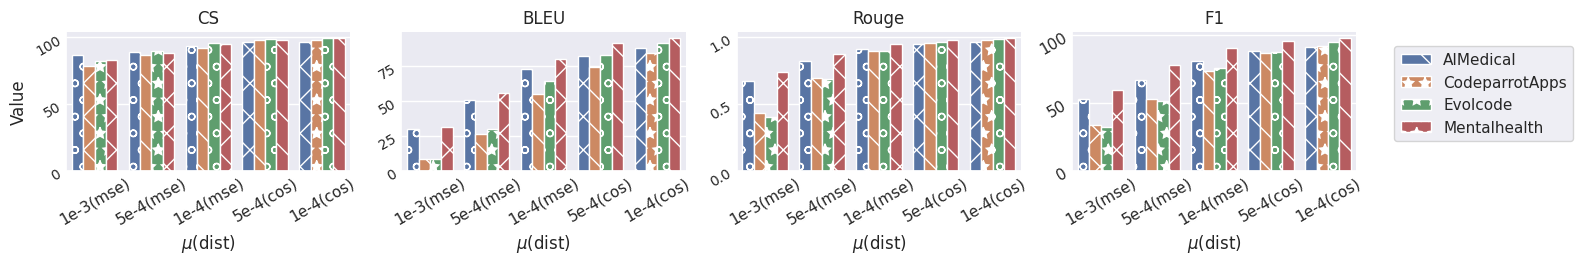

In [4]:
sns.set_theme(style="darkgrid")
g = sns.catplot(x='lr', y='Value', data=df, col='Metric', hue='Dataset', kind='bar', 
                sharey=False, height=2.5, aspect=1.4)
g.set_axis_labels("$\\mu$(dist)", "Value")
g.axes[0][0].set_title('CS')
g.axes[0][1].set_title('BLEU')
g.axes[0][2].set_title('Rouge')
g.axes[0][3].set_title('F1')
hatches = ['o', 'o', 'o', 'x', 'x', 'x', '\\', '\\', '\\', '*', '*', '*'] 
for i, thisbar in enumerate(g.axes[0][0].patches):
    thisbar.set_hatch(hatches[i % len(hatches)])
for i, thisbar in enumerate(g.axes[0][1].patches):
    thisbar.set_hatch(hatches[i % len(hatches)])
for i, thisbar in enumerate(g.axes[0][2].patches):
    thisbar.set_hatch(hatches[i % len(hatches)])
for i, thisbar in enumerate(g.axes[0][3].patches):
    thisbar.set_hatch(hatches[i % len(hatches)])

plt.setp(g.axes[0][2].get_yticklabels(), fontsize=10)
plt.setp(g.axes[0][1].get_yticklabels(), fontsize=10)
plt.setp(g.axes[0][0].get_yticklabels(), fontsize=10)

g.axes[0][0].tick_params(pad=-4, rotation=30)
g.axes[0][1].tick_params(pad=-4, rotation=30)
g.axes[0][2].tick_params(pad=-4, rotation=30)
g.axes[0][3].tick_params(pad=-4, rotation=30)
plt.subplots_adjust(hspace=0., wspace=0.18)
g.legend.remove()

ax = g.axes[0][-1]
handles, _ = ax.get_legend_handles_labels()
new_labels = ['AIMedical', 'CodeparrotApps', 'Evolcode', 'Mentalhealth']
ax.legend(handles, new_labels, title="", loc='upper right', bbox_to_anchor=(1.79, 0.95), ncol=1,)
plt.show()
